1-C’est quoi Naive Bayes ?

Naive Bayes est un algorithme de classification probabiliste.

Il utilise :

- les probabilités
- le théorème de Bayes

Très utilisé pour :

- spam/non spam
- analyse de texte
- sentiment analysis
- classification rapide

1-Pourquoi “Naive” ?

Parce qu’il fait une hypothèse simplificatrice :

toutes les features sont indépendantes entre elles.

Exemple spam :

- mot "gratuit"
- mot "promotion"
- mot "urgent"

Naive Bayes suppose :

chaque mot influence indépendamment le résultat

Ce n’est pas toujours vrai dans la réalité, mais ça marche souvent très bien.

3-Théorème de Bayes

Le cœur de l’algorithme : P(C∣X)=P(X∣C)*P(C)/P(X)
	​
P(C|X)	: probabilité de la classe sachant les données

P(X|C)	: probabilité des données dans la classe

P(C)	: probabilité de la classe

P(X)	: probabilité globale des données

4- Intuition simple

Exemple :

On veut savoir :

cet email est-il un spam ?

Naive Bayes calcule :

Probabilité(spam | mots)

et

Probabilité(non spam | mots)

Puis choisit la plus grande.

5. Types de Naive Bayes

Gaussian NB	: données continues

Multinomial NB :	texte / comptages

Bernoulli NB :	variables binaires

→ on va faire Gaussian Naive Bayes from scratch.

6. Principe 

Pour chaque classe :

- calcul moyenne

- variance

- probabilité

Puis utiliser la loi normale.

Intuition

Si une donnée est proche de la moyenne d’une classe :
→ forte probabilité d’appartenir à cette classe.

In [ ]:
# Importation de NumPy
# Cette bibliothèque permet de faire des calculs mathématiques rapides
# et de manipuler des tableaux numériques.
import numpy as np

# Importation de Pandas
# Pandas permet de créer et manipuler des DataFrames
# pour organiser les données du dataset.
import pandas as pd

# Importation de Matplotlib
# Cette bibliothèque sert à créer les graphes et visualisations.
import matplotlib.pyplot as plt

In [6]:
# ============================================================
# CRÉATION DU DATASET
# ============================================================

# Fixer une graine aléatoire permet d'obtenir les mêmes résultats
# à chaque exécution du notebook.
np.random.seed(7)

# Nombre d'observations
m = 100

# Génération de la superficie des maisons
superficie = np.random.randint(50, 220, m)

# Génération du nombre de chambres
chambres = np.random.randint(1, 6, m)

# Génération de l'âge des maisons
age_maison = np.random.randint(0, 40, m)

# Génération de la distance au centre-ville
distance_centre = np.round(np.random.uniform(1, 20, m), 2)

# Bruit aléatoire pour rendre les données plus réalistes
bruit = np.random.normal(0, 50, m)

# Création du prix
prix = (
    250
    + 7.5 * superficie
    + 60 * chambres
    - 4.5 * age_maison
    - 20 * distance_centre
    + bruit
)

# Création du DataFrame
df = pd.DataFrame({
    "superficie": superficie,
    "chambres": chambres,
    "age_maison": age_maison,
    "distance_centre": distance_centre,
    "prix": np.round(prix, 2)
})

# Création d'une classe binaire :
# 0 = maison moins chère que la médiane
# 1 = maison chère ou égale à la médiane
df["classe_prix"] = (df["prix"] >= df["prix"].median()).astype(int)

# Exportation du dataset pour le rendu
df.to_csv("dataset_naive_bayes.csv", index=False)

# Affichage des premières lignes
df.head()

,superficie,chambres,age_maison,distance_centre,prix,classe_prix
0,75,5,11,19.73,770.88,0
1,117,4,32,8.09,971.54,0
2,201,2,36,13.92,1378.10,1
3,153,3,5,3.32,1529.47,1
4,142,5,28,2.76,1444.42,1


In [7]:
# ============================================================
# FONCTIONS UTILES
# ============================================================

def split_train_test(X, y, test_ratio=0.2, seed=42):
    """
    Sépare manuellement les données en train/test.
    """
    np.random.seed(seed)

    indices = np.random.permutation(len(X))
    taille_test = int(len(X) * test_ratio)

    indices_test = indices[:taille_test]
    indices_train = indices[taille_test:]

    return X[indices_train], X[indices_test], y[indices_train], y[indices_test]


def normaliser_train_test(X_train, X_test):
    """
    Normalise les données avec la moyenne et l'écart-type du train.
    """
    moyenne = X_train.mean(axis=0)
    ecart_type = X_train.std(axis=0)

    # Éviter division par zéro
    ecart_type[ecart_type == 0] = 1

    X_train_norm = (X_train - moyenne) / ecart_type
    X_test_norm = (X_test - moyenne) / ecart_type

    return X_train_norm, X_test_norm, moyenne, ecart_type


def taux_erreur(y_true, y_pred):
    """
    Calcule le taux d'erreur de classification.
    """
    return np.mean(y_true != y_pred)


def matrice_confusion(y_true, y_pred):
    """
    Calcule une matrice de confusion binaire.
    
    [[TN, FP],
     [FN, TP]]
    """
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))

    return np.array([[tn, fp], [fn, tp]])

In [8]:
# ============================================================
# PRÉPARATION DES DONNÉES
# ============================================================

# Variables explicatives
X = df[["superficie", "chambres", "age_maison", "distance_centre"]].values.astype(float)

# Variable cible
y = df["classe_prix"].values.astype(int)

# Séparation train/test
X_train, X_test, y_train, y_test = split_train_test(X, y)

# Normalisation
X_train_norm, X_test_norm, moyenne, ecart_type = normaliser_train_test(X_train, X_test)

print("Taille X_train :", X_train_norm.shape)
print("Taille X_test :", X_test_norm.shape)

Taille X_train : (80, 4)
Taille X_test : (20, 4)


In [ ]:
# ============================================================
# GAUSSIAN NAIVE BAYES 
# ============================================================

class GaussianNaiveBayes:
    """
    Implémentation from scratch de Gaussian Naive Bayes.
    
    Principe :
    - calculer P(classe)
    - calculer moyenne et variance de chaque feature par classe
    - calculer P(X|classe) avec la loi normale
    - choisir la classe avec la probabilité la plus grande
    """

    def fit(self, X, y):
        """
        Phase d'entraînement.
        """
        # Classes possibles : 0 et 1
        self.classes = np.unique(y)

        # Dictionnaires pour stocker les paramètres par classe
        self.moyennes = {}
        self.variances = {}
        self.priors = {}

        # Pour chaque classe, calculer les statistiques
        for c in self.classes:
            # Sélection des exemples appartenant à la classe c
            X_c = X[y == c]

            # Moyenne de chaque variable pour cette classe
            self.moyennes[c] = X_c.mean(axis=0)

            # Variance de chaque variable pour cette classe
            self.variances[c] = X_c.var(axis=0)

            # Probabilité a priori P(c)
            self.priors[c] = len(X_c) / len(X)

    def gaussian_density(self, c, x):
        """
        Calcule la densité gaussienne P(x|classe).
        """
        mean = self.moyennes[c]
        var = self.variances[c]

        # Éviter la division par zéro
        var = var + 1e-9

        numerator = np.exp(-((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)

        return numerator / denominator

    def predict_one(self, x):
        """
        Prédit la classe d'une seule observation.
        """
        posteriors = []

        for c in self.classes:
            # log(P(c))
            prior = np.log(self.priors[c])

            # log(P(X|c))
            likelihood = np.sum(np.log(self.gaussian_density(c, x)))

            # log(P(c|X)) proportionnel à log(P(c)) + log(P(X|c))
            posterior = prior + likelihood

            posteriors.append(posterior)

        # Retourner la classe avec le score le plus élevé
        return self.classes[np.argmax(posteriors)]

    def predict(self, X):
        """
        Prédit les classes pour plusieurs observations.
        """
        return np.array([self.predict_one(x) for x in X])

In [10]:
# Création du modèle
model_nb = GaussianNaiveBayes()

# Entraînement
model_nb.fit(X_train_norm, y_train)

print("Modèle Naive Bayes entraîné avec succès.")

Modèle Naive Bayes entraîné avec succès.


In [11]:
# Prédictions
y_pred = model_nb.predict(X_test_norm)

# Calcul du taux d'erreur
erreur = taux_erreur(y_test, y_pred)

# Matrice de confusion
mc = matrice_confusion(y_test, y_pred)

print("Taux d'erreur :", erreur)
print("Matrice de confusion :")
print(mc)

Taux d'erreur : 0.15
Matrice de confusion :
[[9 0]
 [3 8]]


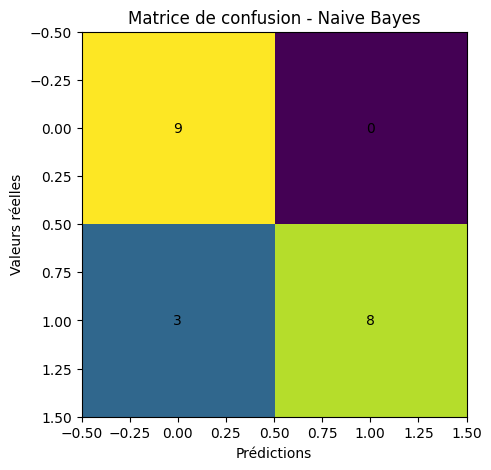

In [12]:
# ============================================================
# VISUALISATION DE LA MATRICE DE CONFUSION
# ============================================================

plt.figure(figsize=(5, 5))

# Affichage de la matrice sous forme d'image
plt.imshow(mc)

plt.title("Matrice de confusion - Naive Bayes")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")

# Affichage des valeurs dans les cases
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            mc[i, j],
            ha="center",
            va="center"
        )

# Sauvegarde du graphe
plt.savefig("matrice_confusion_naive_bayes.png")

plt.show()

In [13]:
print("Résumé Naive Bayes")
print("-------------------")
print("Type :", "Classification supervisée")
print("Version :", "Gaussian Naive Bayes from scratch")
print("Métrique utilisée :", "Taux d'erreur + matrice de confusion")
print("Dataset exporté :", "dataset_naive_bayes.csv")
print("Graphe exporté :", "matrice_confusion_naive_bayes.png")

Résumé Naive Bayes
-------------------
Type : Classification supervisée
Version : Gaussian Naive Bayes from scratch
Métrique utilisée : Taux d'erreur + matrice de confusion
Dataset exporté : dataset_naive_bayes.csv
Graphe exporté : matrice_confusion_naive_bayes.png


On passe au DBSCAN

1. Principe de DBSCAN

Avant le code, comprends l’idée.

DBSCAN est un algorithme de :

- clustering

- apprentissage non supervisé

Contrairement à K-Means :

- il n’a pas besoin du nombre de clusters

- il détecte le bruit (outliers)

- il trouve des formes complexes

2. Principe

DBSCAN cherche :

des zones denses

séparées par des zones peu denses

3. Paramètres importants

eps

Distance maximale entre voisins.

min_samples

Nombre minimal de voisins pour créer un cluster.

4. Types de points

Core point :	point dense

Border point :	proche d’un cluster

Noise point :	bruit/outlier

5. Intuition

Si un point a :

suffisamment de voisins proches

→ il devient un core point.

Puis le cluster grandit autour de lui.

In [ ]:
# ============================================================
# CRÉATION DU DATASET POUR DBSCAN
# ============================================================

# Fixer une graine aléatoire
np.random.seed(42)

# Création du premier cluster
cluster_1 = np.random.randn(60, 2) + np.array([2, 2])

# Création du deuxième cluster
cluster_2 = np.random.randn(60, 2) + np.array([8, 8])

# Création du troisième cluster
cluster_3 = np.random.randn(60, 2) + np.array([2, 8])

# Création de bruit (outliers)
bruit = np.random.uniform(low=-2, high=12, size=(20, 2))

# Fusion des données
X = np.vstack([
    cluster_1,
    cluster_2,
    cluster_3,
    bruit
])

# Création DataFrame
df = pd.DataFrame(X, columns=["x1", "x2"])

# Exportation du dataset
df.to_csv("dataset_dbscan.csv", index=False)

# Affichage
df.head()

,x1,x2
0,2.496714,1.861736
1,2.647689,3.523030
2,1.765847,1.765863
3,3.579213,2.767435
4,1.530526,2.542560


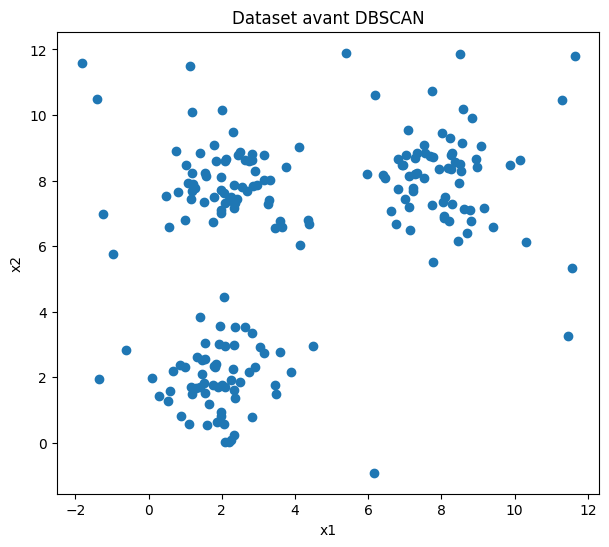

In [15]:
# ============================================================
# VISUALISATION INITIALE DES DONNÉES
# ============================================================

plt.figure(figsize=(7, 6))

plt.scatter(
    df["x1"],
    df["x2"]
)

plt.title("Dataset avant DBSCAN")

plt.xlabel("x1")
plt.ylabel("x2")

plt.savefig("dataset_initial_dbscan.png")

plt.show()

In [16]:
# ============================================================
# DISTANCE EUCLIDIENNE
# ============================================================

def distance_euclidienne(p1, p2):
    """
    Calcule la distance euclidienne entre deux points.
    """
    
    return np.sqrt(
        np.sum((p1 - p2) ** 2)
    )

In [17]:
# ============================================================
# RECHERCHE DES VOISINS
# ============================================================

def trouver_voisins(X, point_idx, eps):
    """
    Retourne les voisins d'un point
    situés à une distance <= eps.
    """
    
    voisins = []
    
    # Point de référence
    point = X[point_idx]
    
    # Tester tous les points
    for i in range(len(X)):
        
        distance = distance_euclidienne(
            point,
            X[i]
        )
        
        # Si distance <= eps
        if distance <= eps:
            voisins.append(i)
    
    return voisins

In [18]:
# ============================================================
# DBSCAN 
# ============================================================

def dbscan(X, eps=1.2, min_samples=5):
    """
    Implémentation from scratch de DBSCAN.
    
    eps :
        distance maximale entre voisins
        
    min_samples :
        nombre minimal de voisins
        pour former un cluster
    """
    
    # Labels des points
    # -1 = bruit
    labels = np.full(len(X), -1)
    
    # Cluster actuel
    cluster_id = 0
    
    # Points déjà visités
    visited = set()
    
    # Parcourir tous les points
    for point_idx in range(len(X)):
        
        # Ignorer si déjà visité
        if point_idx in visited:
            continue
        
        # Marquer comme visité
        visited.add(point_idx)
        
        # Trouver voisins
        voisins = trouver_voisins(
            X,
            point_idx,
            eps
        )
        
        # Si pas assez de voisins
        # alors bruit
        if len(voisins) < min_samples:
            labels[point_idx] = -1
        
        else:
            # Nouveau cluster
            labels[point_idx] = cluster_id
            
            i = 0
            
            # Étendre le cluster
            while i < len(voisins):
                
                voisin_idx = voisins[i]
                
                if voisin_idx not in visited:
                    
                    visited.add(voisin_idx)
                    
                    nouveaux_voisins = trouver_voisins(
                        X,
                        voisin_idx,
                        eps
                    )
                    
                    # Si core point
                    if len(nouveaux_voisins) >= min_samples:
                        voisins.extend(nouveaux_voisins)
                
                # Ajouter au cluster
                if labels[voisin_idx] == -1:
                    labels[voisin_idx] = cluster_id
                
                i += 1
            
            # Cluster suivant
            cluster_id += 1
    
    return labels

In [19]:
# ============================================================
# APPLICATION DE DBSCAN
# ============================================================

# Conversion du DataFrame en matrice numpy
X_dbscan = df.values

# Exécution de DBSCAN
labels = dbscan(
    X_dbscan,
    eps=1.2,
    min_samples=5
)

# Ajouter les clusters au dataset
df["cluster"] = labels

# Affichage des premières lignes
df.head()

,x1,x2,cluster
0,2.496714,1.861736,0
1,2.647689,3.523030,0
2,1.765847,1.765863,0
3,3.579213,2.767435,0
4,1.530526,2.542560,0


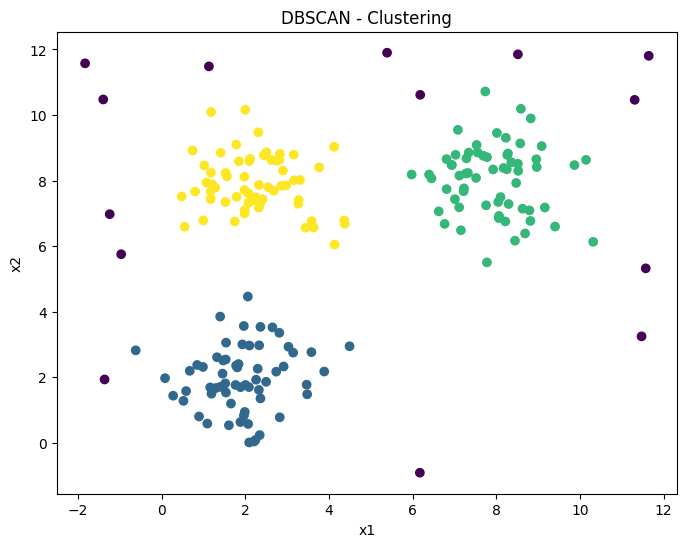

In [20]:
# ============================================================
# VISUALISATION DES CLUSTERS
# ============================================================

plt.figure(figsize=(8, 6))

# Affichage des clusters
scatter = plt.scatter(
    df["x1"],
    df["x2"],
    c=df["cluster"]
)

plt.title("DBSCAN - Clustering")

plt.xlabel("x1")
plt.ylabel("x2")

plt.savefig("resultat_dbscan.png")

plt.show()

In [21]:
print("Résumé DBSCAN")
print("-------------------------")
print("Type :", "Apprentissage non supervisé")
print("Algorithme :", "DBSCAN from scratch")
print("Dataset exporté :", "dataset_dbscan.csv")
print("Graphes exportés :")
print("- dataset_initial_dbscan.png")
print("- resultat_dbscan.png")

# Nombre de clusters détectés
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print("Nombre de clusters :", n_clusters)

# Nombre de points bruit
n_bruit = np.sum(labels == -1)

print("Nombre de points bruit :", n_bruit)

Résumé DBSCAN
-------------------------
Type : Apprentissage non supervisé
Algorithme : DBSCAN from scratch
Dataset exporté : dataset_dbscan.csv
Graphes exportés :
- dataset_initial_dbscan.png
- resultat_dbscan.png
Nombre de clusters : 3
Nombre de points bruit : 14
